# Pipeline — ¿a qué precio se revende una entrada?
### Proyecto de pasantía · Analítica de Datos · Negocios Digitales · UdeSA · Otoño 2026

---

Arrancaste una **pasantía en Pipeline**, un marketplace de reventa de entradas. Tu jefa te sienta el lunes:

> *"La gente no sabe a cuánto publicar. Si pide muy caro no vende y no cobramos ninguno de los dos; si pide muy barato siente que la estafamos y se va. Queremos mostrarle un **precio sugerido**. Te doy un export de la base, lo vemos la semana que viene."*

Eso es todo lo que tenés.

1. ¿A qué precio se revende una entrada como la mía? → un número → **regresión** (secciones 2 a 10).
2. Si publico a ese precio, ¿se va a vender? → sí o no → **clasificación** (sección 11).

> **Cómo usar este notebook.** Primero mirá cada output y preguntate qué ves; recién después leé la explicación. La mitad del trabajo de un analista es **darse cuenta**.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 12

SEMILLA = 42

In [2]:
def pesos(monto):
    """Formatea un numero como plata argentina: 74000 -> $74.000"""
    return "$" + f"{monto:,.0f}".replace(",", ".")


def rmse(y_real, y_pred):
    """Raiz del error cuadratico medio, en la misma unidad que el target."""
    return np.sqrt(mean_squared_error(y_real, y_pred))


def tabla_metricas(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Fila con las metricas del modelo en train y en test."""
    pred_tr, pred_te = modelo.predict(X_tr), modelo.predict(X_te)
    return {"Modelo": nombre,
            "RMSE train": rmse(y_tr, pred_tr), "RMSE test": rmse(y_te, pred_te),
            "MAE test": mean_absolute_error(y_te, pred_te),
            "R2 train": r2_score(y_tr, pred_tr), "R2 test": r2_score(y_te, pred_te)}

In [3]:
try:
    from ipywidgets import interact, IntSlider
    HAY_WIDGETS = True
except ImportError:
    HAY_WIDGETS = False
    print("Sin ipywidgets: los graficos estaticos funcionan igual.")

---
## 2. Primer contacto con los datos

Abrimos el export y lo miramos con **una pregunta concreta**: ¿qué tiene esto de raro?

In [4]:
df = pd.read_csv("reventa_entradas.csv")
print(f"{df.shape[0]} publicaciones x {df.shape[1]} columnas")
df.head()

2186 publicaciones x 18 columnas


,id_publicacion,genero_musical,oyentes_mensuales_spotify,capacidad_venue,tipo_venue,sector,precio_original,precio_original_con_cargos,dias_hasta_el_show,dia_semana_show,show_agotado_en_preventa,vendedor_verificado,cantidad_entradas_publicadas,cantidad_fotos_publicacion,precio_publicado,se_vendio,comision_plataforma,precio_reventa
0,P00826,Electronica,4346767,8400,Arena,Campo,52000,60000,22,Viernes,No,No,2.0,3.0,70000,1,10000.0,70000.0
1,P01270,Trap,843108,3300,Teatro,Campo,46000,53900,8,Viernes,No,Si,2.0,1.0,68000,1,10000.0,68000.0
2,P00986,Indie,13744934,25000,Estadio,CAMPO,57000,68900,23,Jueves,Si,Si,1.0,8.0,158000,1,24000.0,158000.0
3,P01204,Indie,10211935,15000,Arena,Platea Alta,44000,52700,47,Jueves,No,Si,3.0,5.0,68000,1,10000.0,68000.0
4,P00438,Cumbia,351766,3300,Teatro,General,22000,25700,21,Martes,No,Si,4.0,3.0,23000,1,3000.0,23000.0


In [5]:
df.describe()

,oyentes_mensuales_spotify,capacidad_venue,precio_original,precio_original_con_cargos,dias_hasta_el_show,cantidad_entradas_publicadas,cantidad_fotos_publicacion,precio_publicado,se_vendio,comision_plataforma,precio_reventa
count,2.186000e+03,2186.000000,2186.000000,2186.000000,2186.000000,2137.000000,2134.000000,2.186000e+03,2186.000000,1.406000e+03,1.406000e+03
mean,8.641386e+06,16707.410796,52525.617566,62998.215919,18.073193,2.117922,4.507029,2.137369e+05,0.643184,3.816358e+04,2.545141e+05
std,1.524047e+07,22027.811212,28923.358565,34652.216806,48.626848,1.133480,2.329955,2.867800e+06,0.479169,5.362443e+05,3.574922e+06
min,5.000000e+04,1100.000000,18000.000000,21500.000000,0.000000,1.000000,1.000000,1.500000e+04,0.000000,2.000000e+03,1.500000e+04
25%,3.488788e+05,3300.000000,35000.000000,42400.000000,6.000000,1.000000,2.000000,5.825000e+04,0.000000,8.000000e+03,5.025000e+04
50%,1.813122e+06,8400.000000,47000.000000,55900.000000,14.000000,2.000000,4.500000,8.800000e+04,1.000000,1.100000e+04,7.400000e+04
75%,9.040671e+06,15000.000000,59000.000000,70800.000000,23.000000,2.000000,7.000000,1.297500e+05,1.000000,1.600000e+04,1.080000e+05
max,6.000000e+07,84000.000000,198000.000000,230100.000000,999.000000,6.000000,8.000000,9.900000e+07,1.000000,1.485000e+07,9.900000e+07


**Pará acá y buscá vos.** Hay por lo menos cuatro cosas raras en ese `describe()`.

...

1. `dias_hasta_el_show` llega a **999**. Es el clásico 999 usado como *valor faltante*.
2. `precio_reventa` llega a **$99.000.000** contra una mediana de ~$74.000. Alguien publicó "por las dudas".
3. `oyentes_mensuales_spotify` va de **50.000 a 60 millones**. Rango gigantesco: vuelve en la sección 11.
4. `precio_reventa` y `comision_plataforma` tienen **menos filas que el resto**: son las publicaciones que **no se vendieron**.

El punto 4 es el más importante: el dataset tiene **dos poblaciones mezcladas**.

Ahora las categóricas. Como todavía no sabemos cuáles están bien cargadas, les tiramos `value_counts()` **a todas** — no hay forma de saber cuál está sucia sin mirarlas.

In [6]:
categoricas = [columna for columna in df.columns
               if not pd.api.types.is_numeric_dtype(df[columna]) and columna != "id_publicacion"]

for columna in categoricas:
    print(f"--- {columna}  ({df[columna].nunique()} valores unicos) ---")
    print(df[columna].value_counts().to_string())
    print()

--- genero_musical  (6 valores unicos) ---
genero_musical
Rock nacional        569
Trap                 490
Pop internacional    411
Cumbia               260
Indie                242
Electronica          214

--- tipo_venue  (4 valores unicos) ---
tipo_venue
Arena      862
Estadio    544
Club       508
Teatro     272

--- sector  (17 valores unicos) ---
sector
Campo          548
Platea Baja    487
Platea Alta    366
General        343
Palco          118
campo           50
general         34
platea baja     34
CAMPO           31
GENERAL         28
PLATEA BAJA     27
Pl. Baja        26
Pl. Alta        25
PLATEA ALTA     24
palco           20
platea alta     15
PALCO           10

--- dia_semana_show  (7 valores unicos) ---
dia_semana_show
Viernes      577
Sabado       552
Jueves       355
Domingo      227
Miercoles    201
Martes       141
Lunes        133

--- show_agotado_en_preventa  (2 valores unicos) ---
show_agotado_en_preventa
No    1604
Si     582

--- vendedor_verificado  (2 valo

**`sector` tiene 17 valores únicos cuando deberían ser 5**: "Platea Baja", "platea baja", "PLATEA BAJA" y "Pl. Baja" son la misma cosa. El resto está bien.

Por eso a las categóricas se les mira el conteo **siempre**, aunque doce de trece estén perfectas: **la que está mal no avisa**.

---
## 3. Limpieza

Nada glamoroso, y es donde se va la mitad del tiempo de cualquier proyecto real.

In [7]:
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)


def normalizar_sector(valor):
    """Lleva las variantes de escritura a las 5 categorias reales."""
    texto = str(valor).strip().lower().replace(".", "").replace("pl ", "platea ")
    if texto.startswith("general"):
        return "General"
    if texto.startswith("platea alta"):
        return "Platea Alta"
    if texto.startswith("platea baja"):
        return "Platea Baja"
    if texto.startswith("campo"):
        return "Campo"
    return "Palco"


df["sector"] = df["sector"].apply(normalizar_sector)

for columna in ["cantidad_fotos_publicacion", "cantidad_entradas_publicadas"]:
    df[columna] = df[columna].fillna(df[columna].median())

print(f"{len(df)} publicaciones | {df['sector'].nunique()} sectores")

Filas duplicadas exactas: 6
2180 publicaciones | 5 sectores


### 3.1 Los valores imposibles

El reflejo es "corro IQR y saco todo lo que quede afuera". **Está mal.** Un valor extremo puede ser dos cosas:

- **Basura**: el `999` en días (un faltante disfrazado) y la entrada a $99.000.000.
- **Un caso extremo pero real**: un palco de River a varias veces el valor de lista. Ese **es el caso que nos pidieron predecir**.

Así que en vez de aplicar una fórmula, **miramos dónde cortar**.

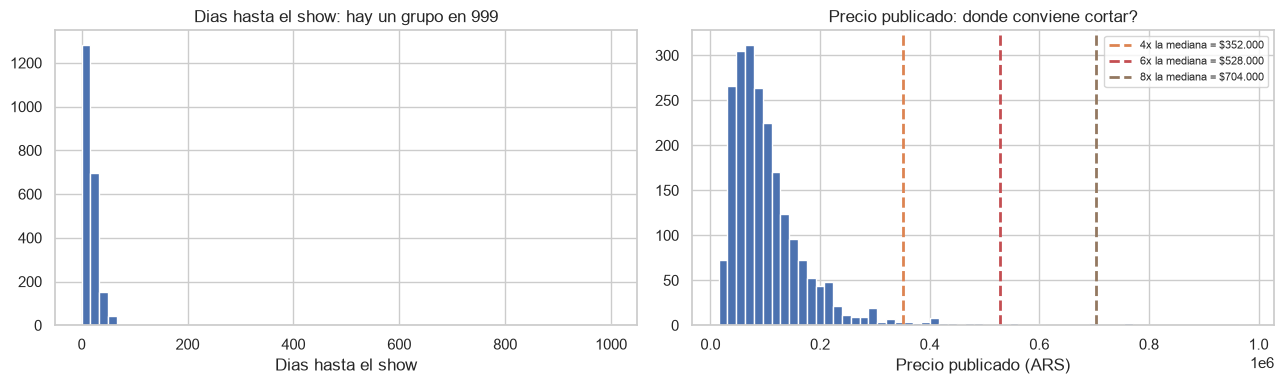

Cortando en 4x la mediana quedan afuera  44 publicaciones (2.02%)
Cortando en 6x la mediana quedan afuera  12 publicaciones (0.55%)
Cortando en 8x la mediana quedan afuera   8 publicaciones (0.37%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["dias_hasta_el_show"], bins=60, color="#4C72B0")
axes[0].set_title("Dias hasta el show: hay un grupo en 999")
axes[0].set_xlabel("Dias hasta el show")

precio = df["precio_publicado"]
mediana = precio.median()
axes[1].hist(precio[precio < mediana * 12], bins=60, color="#4C72B0")
for corte, color in [(4, "#DD8452"), (6, "#C44E52"), (8, "#937860")]:
    axes[1].axvline(mediana * corte, color=color, linestyle="--", linewidth=2,
                    label=f"{corte}x la mediana = {pesos(mediana * corte)}")
axes[1].set_title("Precio publicado: donde conviene cortar?")
axes[1].set_xlabel("Precio publicado (ARS)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

for corte in [4, 6, 8]:
    quedan_afuera = (precio > mediana * corte).sum()
    print(f"Cortando en {corte}x la mediana quedan afuera {quedan_afuera:>3} publicaciones "
          f"({100 * quedan_afuera / len(df):.2f}%)")

**Así se elige un corte: mirando, no adivinando.** En 4x sacaríamos palcos legítimos; en 8x dejamos adentro precios que no son precios. **6x deja afuera menos del 1%**, y justo las que no tienen sentido.

Orden de magnitud: una limpieza honesta saca **una fracción de un por ciento**. Si sacás el 10%, no estás limpiando: estás recortando la realidad para que le entre al modelo.

In [9]:
antes = len(df)
df = df[df["dias_hasta_el_show"] <= 60]
df = df[df["precio_publicado"] <= df["precio_publicado"].median() * 6]
df = df.reset_index(drop=True)

for columna in ["show_agotado_en_preventa", "vendedor_verificado"]:
    df[columna] = (df[columna] == "Si").astype(int)

print(f"Sacamos {antes - len(df)} filas de {antes}. Quedan {len(df)} publicaciones.")
print(f"De esas, se vendieron {df['se_vendio'].sum()} ({100 * df['se_vendio'].mean():.1f}%)")

Sacamos 17 filas de 2180. Quedan 2163 publicaciones.
De esas, se vendieron 1393 (64.4%)


### 3.2 Separamos las dos poblaciones

Las secciones 4 a 10 responden *"¿a cuánto se vende?"*, así que solo pueden mirar las que **se vendieron**: las otras no tienen precio de venta, e incluirlas sería inventar datos. La sección 11 vuelve a usar **todas**.

In [10]:
vendidas = df[df["se_vendio"] == 1].reset_index(drop=True)
print(f"Para la pregunta 1 (a cuanto se vende): {len(vendidas)} publicaciones vendidas")
print(f"Para la pregunta 2 (se vende o no):     {len(df)} publicaciones en total")

Para la pregunta 1 (a cuanto se vende): 1393 publicaciones vendidas
Para la pregunta 2 (se vende o no):     2163 publicaciones en total


---
## 4. EDA — mirar el target antes que nada

La forma del target condiciona todo lo que viene después.

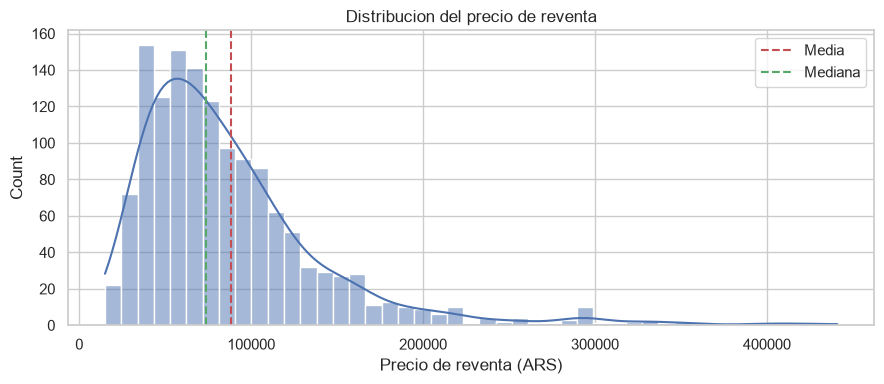

Media $88.282 | Mediana $74.000 | Asimetria 2.27


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(vendidas["precio_reventa"], bins=45, kde=True, ax=ax, color="#4C72B0")
ax.axvline(vendidas["precio_reventa"].mean(), color="#C44E52", linestyle="--", label="Media")
ax.axvline(vendidas["precio_reventa"].median(), color="#55A868", linestyle="--", label="Mediana")
ax.set_title("Distribucion del precio de reventa")
ax.set_xlabel("Precio de reventa (ARS)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Media {pesos(vendidas['precio_reventa'].mean())} | "
      f"Mediana {pesos(vendidas['precio_reventa'].median())} | "
      f"Asimetria {vendidas['precio_reventa'].skew():.2f}")

**Cola a la derecha**: la media queda por encima de la mediana, porque unos pocos palcos carísimos tiran el promedio.

Consecuencia práctica: **la media miente**. El "precio típico de reventa" honesto es la **mediana** ($74.000).

---
## 5. EDA — buscando qué explica el precio

Acá no hay atajo: se grafica **todo contra el target** y se ve qué aparece. La mayoría de los gráficos no va a decir nada, y eso también es información.

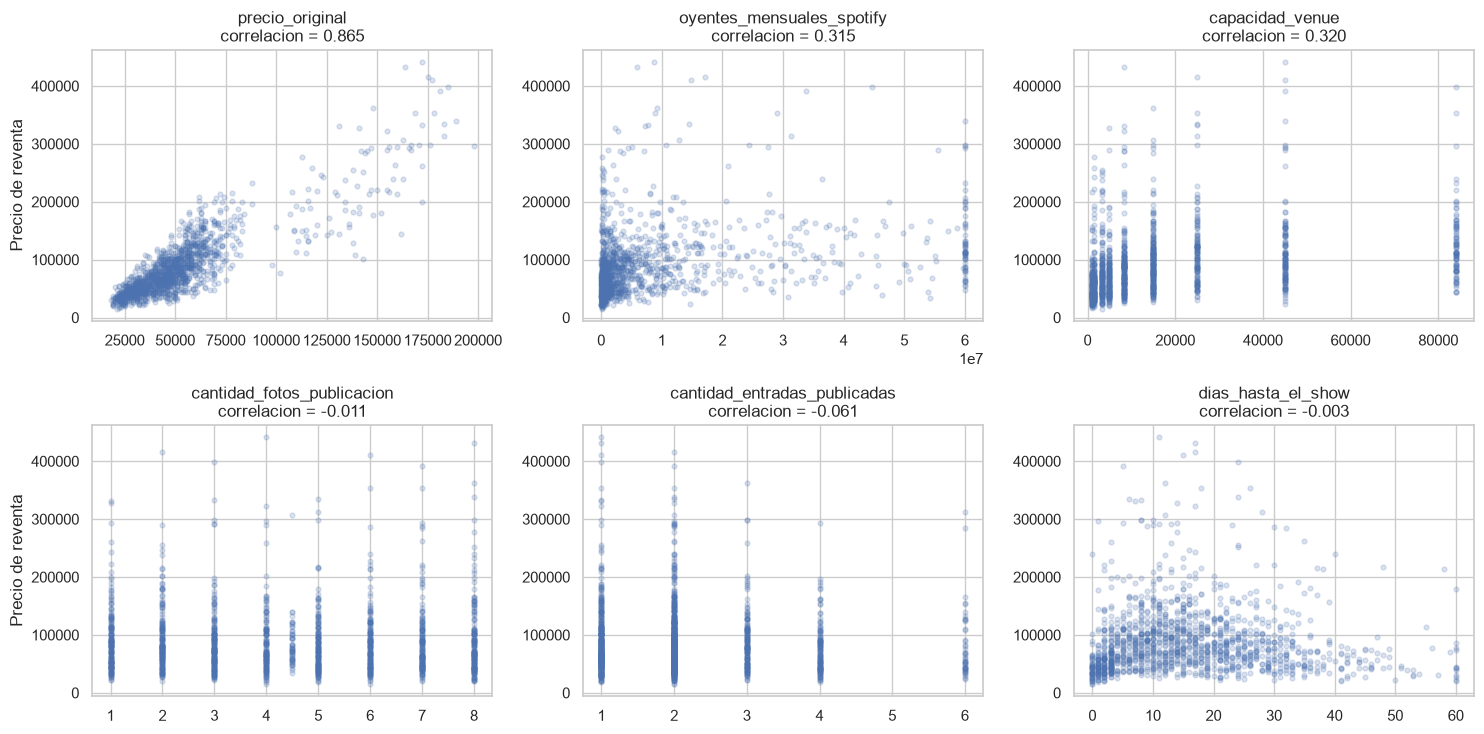

In [12]:
candidatas = ["precio_original", "oyentes_mensuales_spotify", "capacidad_venue",
              "cantidad_fotos_publicacion", "cantidad_entradas_publicadas", "dias_hasta_el_show"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, variable in zip(axes.flat, candidatas):
    correlacion = vendidas[variable].corr(vendidas["precio_reventa"])
    ax.scatter(vendidas[variable], vendidas["precio_reventa"], alpha=0.2, s=12, color="#4C72B0")
    ax.set_title(f"{variable}\ncorrelacion = {correlacion:.3f}")
    ax.set_xlabel("")
axes[0, 0].set_ylabel("Precio de reventa")
axes[1, 0].set_ylabel("Precio de reventa")
plt.tight_layout()
plt.show()

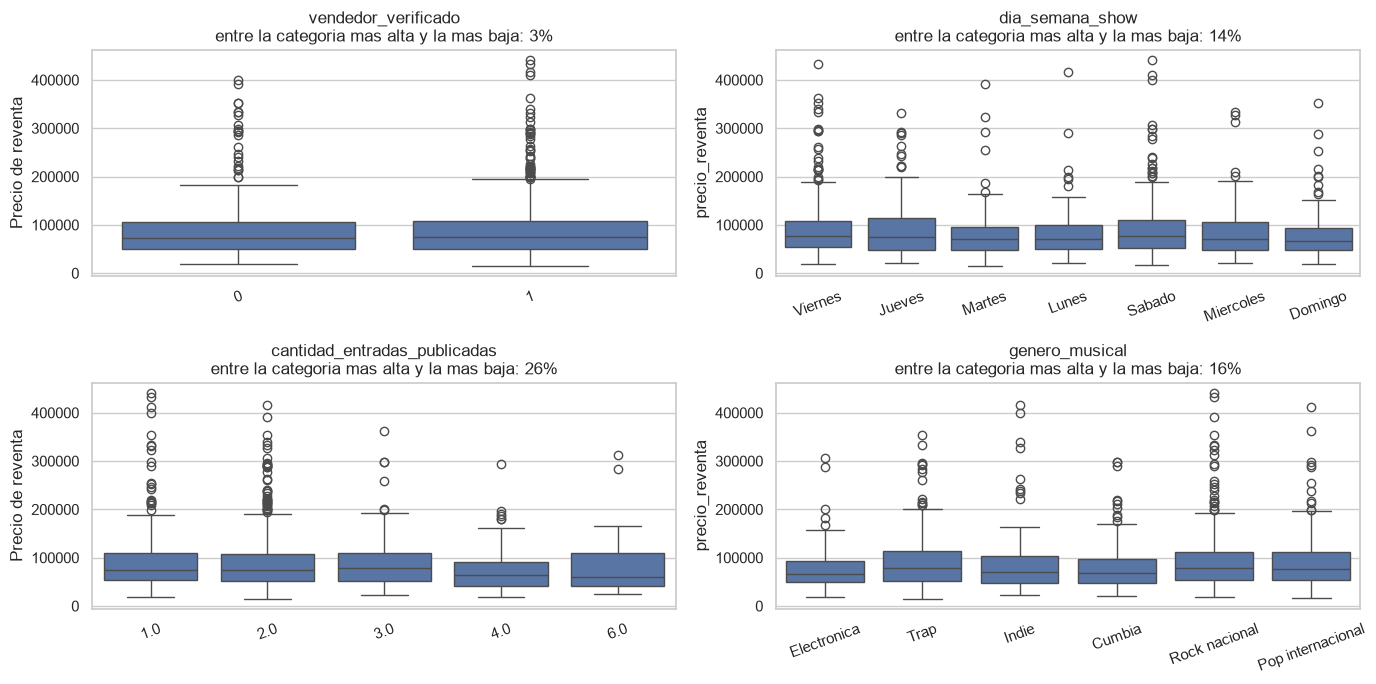

In [13]:
# Y ahora las categoricas. Mismo criterio: las graficamos todas y vemos que queda.
categoricas_eda = ["vendedor_verificado", "dia_semana_show",
                   "cantidad_entradas_publicadas", "genero_musical"]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, variable in zip(axes.flat, categoricas_eda):
    sns.boxplot(data=vendidas, x=variable, y="precio_reventa", ax=ax)
    medianas = vendidas.groupby(variable, observed=True)["precio_reventa"].median()
    separacion = 100 * (medianas.max() - medianas.min()) / vendidas["precio_reventa"].median()
    ax.set_title(f"{variable}\nentre la categoria mas alta y la mas baja: {separacion:.0f}%")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
axes[0, 0].set_ylabel("Precio de reventa")
axes[1, 0].set_ylabel("Precio de reventa")
plt.tight_layout()
plt.show()

**Diez gráficos y el saldo es flaco:**

- **`precio_original`** (0,87): el driver principal.
- **`oyentes` y `capacidad_venue`** (0,32 las dos): aportan, pero poco. Y se parecen sospechosamente entre sí — volvemos sobre eso en 6.1.
- **`vendedor_verificado`**: nada. Estar verificado mueve la mediana **$2.000 sobre $74.000**.
- **`dia_semana_show`**: casi nada. Viernes y sábado apenas por encima.
- **`cantidad_fotos`, `cantidad_entradas`, `genero_musical`**: nada o cerca de nada.
- **`dias_hasta_el_show`**: **-0,003**. Cero pelado.

Y así es como se trabaja de verdad: **de diez gráficos, siete no dicen nada**. No los hiciste al pedo — los hiciste para poder descartarlos, y ese descarte es parte del resultado.

El laburo está en darte cuenta de cuál de esos siete está mintiendo. **Acá hay uno que miente.**

### 5.1 Por qué esa nube no muestra nada

Estamos **mezclando peras con manzanas**: ahí conviven generales de $18.000 con palcos de $200.000, y esa variación tapa todo lo demás.

**Neutralicémosla.** En vez del precio, miremos el **multiplicador**: cuántas veces el valor de lista se está pagando. Es una variable que **no viene en el CSV** — la construimos nosotros.

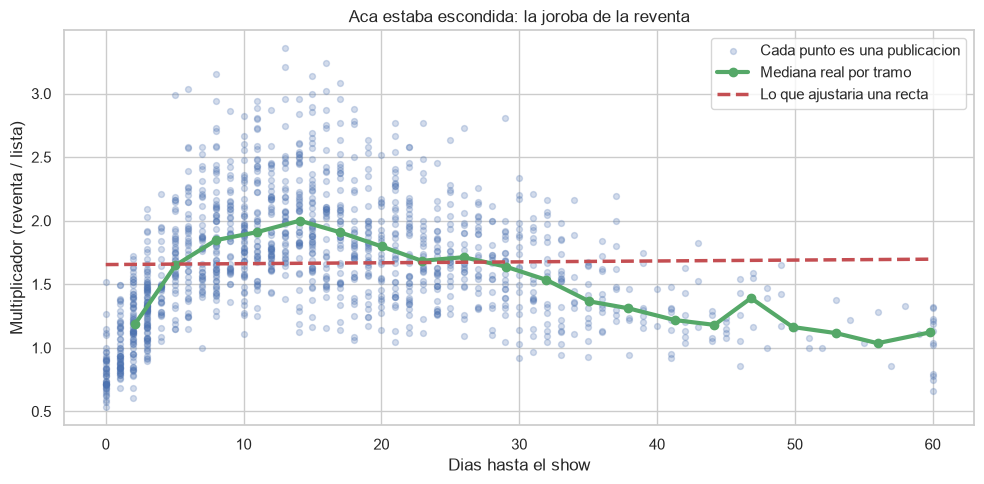

Multiplicador: minimo 0.53x | mediano 1.64x | maximo 3.35x
Correlacion con el multiplicador: 0.018


In [14]:
vendidas["multiplicador"] = vendidas["precio_reventa"] / vendidas["precio_original"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(vendidas["dias_hasta_el_show"], vendidas["multiplicador"],
           alpha=0.25, s=18, color="#4C72B0", label="Cada punto es una publicacion")

tramos = pd.cut(vendidas["dias_hasta_el_show"], bins=np.arange(0, 62, 3))
resumen = vendidas.groupby(tramos, observed=True).agg(
    dias_medio=("dias_hasta_el_show", "mean"), mult_mediano=("multiplicador", "median"))
ax.plot(resumen["dias_medio"], resumen["mult_mediano"],
        color="#55A868", linewidth=3, marker="o", label="Mediana real por tramo")

coef = np.polyfit(vendidas["dias_hasta_el_show"], vendidas["multiplicador"], 1)
grilla = np.linspace(0, 60, 100)
ax.plot(grilla, np.polyval(coef, grilla), color="#C44E52", linewidth=2.5,
        linestyle="--", label="Lo que ajustaria una recta")

ax.set_xlabel("Dias hasta el show")
ax.set_ylabel("Multiplicador (reventa / lista)")
ax.set_title("Aca estaba escondida: la joroba de la reventa")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Multiplicador: minimo {vendidas['multiplicador'].min():.2f}x | "
      f"mediano {vendidas['multiplicador'].median():.2f}x | "
      f"maximo {vendidas['multiplicador'].max():.2f}x")
print(f"Correlacion con el multiplicador: "
      f"{vendidas['dias_hasta_el_show'].corr(vendidas['multiplicador']):.3f}")

**Ahí está, y cuenta sola una historia de negocio:**

- **Un mes antes**: ~1,3x. Poca urgencia.
- **Entre 10 y 20 días**: el pico, casi **2x**. El show se agotó y la reventa es la única forma de entrar.
- **Últimos dos días**: se desploma. **El día del show cae por debajo de 1x.**

La recta roja **queda plana** porque la relación sube y baja, y lo que sube se cancela con lo que baja.

> **Correlación cero no significa "no hay relación". Significa "no hay relación LINEAL".**

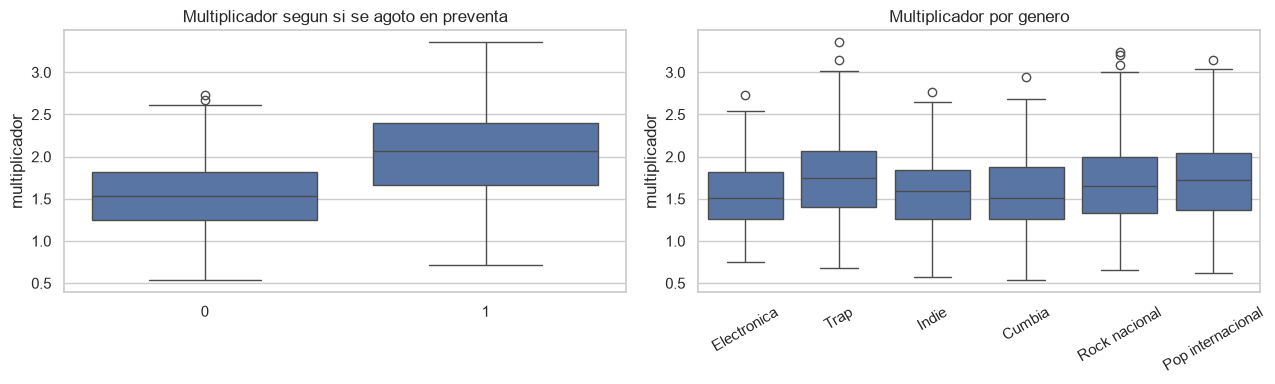

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=vendidas, x="show_agotado_en_preventa", y="multiplicador", ax=axes[0])
axes[0].set_title("Multiplicador segun si se agoto en preventa")
sns.boxplot(data=vendidas, x="genero_musical", y="multiplicador", ax=axes[1])
axes[1].set_title("Multiplicador por genero")
axes[1].tick_params(axis="x", rotation=30)
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Que el show se haya agotado** es el corte más violento del dataset: las cajas casi no se tocan. Sin entradas oficiales, la reventa es el único canal.

**El género** separa menos, pero separa. Ojo con leerlo como "la cumbia vale menos": lo que dice es que **esos shows se agotan menos**, no que el público valore menos.

---
## 6. Qué variables entran al modelo

Esta decisión pesa más que la elección del algoritmo. Empecemos por el mapa completo.

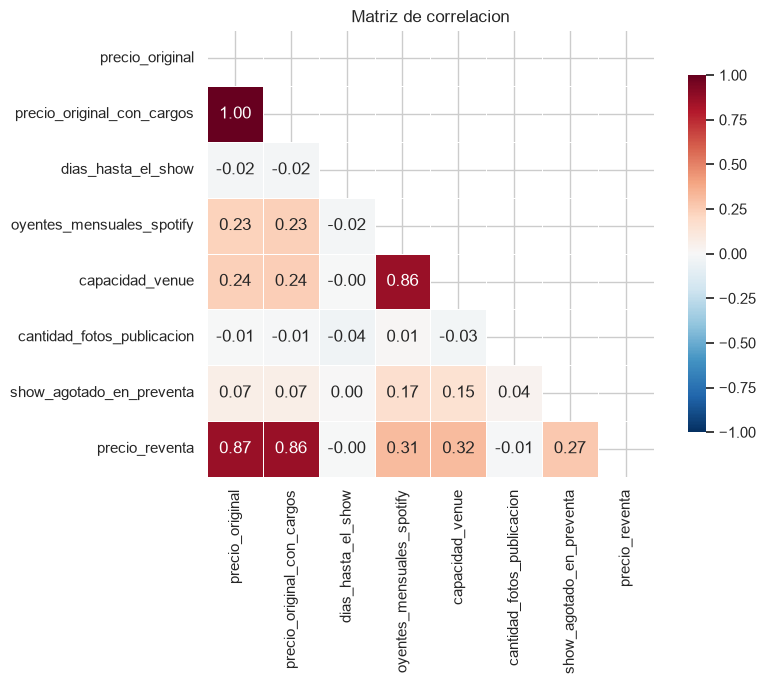

In [16]:
numericas = ["precio_original", "precio_original_con_cargos", "dias_hasta_el_show",
             "oyentes_mensuales_spotify", "capacidad_venue",
             "cantidad_fotos_publicacion", "show_agotado_en_preventa", "precio_reventa"]

fig, ax = plt.subplots(figsize=(9, 7))
matriz = vendidas[numericas].corr()
sns.heatmap(matriz, mask=np.triu(np.ones_like(matriz, dtype=bool)), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlacion")
plt.tight_layout()
plt.show()

*(La **correlación** es la covarianza dividida por los desvíos. Se usa ella porque la covarianza **tiene unidades** —"oyentes por peso"— y no se puede comparar entre pares.)*

1. **`precio_original` y `precio_original_con_cargos`: 1,00** → **multicolinealidad** (6.1)
2. **`cantidad_fotos_publicacion`: -0,01** → **ruido** (6.2)
3. **`oyentes_mensuales_spotify` y `capacidad_venue`: 0,86 entre ellas.** Un artista con más oyentes toca en un venue más grande. Es el mismo problema que 1, más suave → **también multicolinealidad**
4. **`dias_hasta_el_show`: cero** — y ya sabemos que es mentira: el heatmap solo ve relaciones lineales.

Falta la peor, en 6.3.

### 6.1 Multicolinealidad: cuando dos variables dicen lo mismo

El cargo por servicio es un porcentaje fijo: la columna con cargos es **el precio de lista × 1,20**. Un dato escrito dos veces. Probemos dos modelos idénticos salvo por eso.

In [17]:
y = vendidas["precio_reventa"]
cols_a = ["precio_original", "precio_original_con_cargos", "show_agotado_en_preventa"]
cols_b = ["precio_original", "show_agotado_en_preventa"]

for nombre, cols in [("A - con los dos precios", cols_a), ("B - solo precio_original", cols_b)]:
    modelo = LinearRegression().fit(vendidas[cols], y)
    print(f"MODELO {nombre}")
    for columna, coef in zip(cols, modelo.coef_):
        print(f"   {columna:30s} {coef:>12,.2f}")
    print(f"   R2: {modelo.score(vendidas[cols], y):.4f}\n")

MODELO A - con los dos precios
   precio_original                        2.85
   precio_original_con_cargos            -0.94
   show_agotado_en_preventa          27,106.82
   R2: 0.7938

MODELO B - solo precio_original
   precio_original                        1.73
   show_agotado_en_preventa          27,209.43
   R2: 0.7930



**El R² es prácticamente el mismo**, así que el precio con cargos no aportó nada. Pero el coeficiente del precio de lista pasó a **2,85** y el de cargos quedó en **-0,94**: *cada peso de cargo bajaría el precio de reventa 94 centavos*. No tiene sentido.

**¿Por qué?** Si `P` es el precio de lista, la columna con cargos es `1,20 × P`:

```
a·P  +  b·(1,20·P)   =   (a + 1,20·b) · P
```

**Lo único determinado es la suma.** Comprobalo: `2,85 + 1,20×(−0,94) = 1,72`, y el modelo B dio **1,73**. El −0,94 es el **contrapeso** del 2,85 inflado, no un hallazgo sobre el mundo.

Es como preguntar cuánto aporta el zapato izquierdo y cuánto el derecho al precio de un par: siempre vienen juntos.

Para **predecir** casi no molesta; para **explicar** lo arruina. **Decisión: sacamos `precio_original_con_cargos`.**

**Y hay un segundo caso, más suave.** En el heatmap vimos que `oyentes_mensuales_spotify` y `capacidad_venue` correlacionan **0,86** entre sí: un artista con más oyentes toca en un venue más grande.

Acá los coeficientes no se vuelven locos como antes, así que hace falta otra prueba: **¿la segunda variable aporta algo que la primera no?**

In [18]:
combinaciones = [("Solo precio_original", ["precio_original"]),
                 ("+ capacidad_venue", ["precio_original", "capacidad_venue"]),
                 ("+ oyentes", ["precio_original", "oyentes_mensuales_spotify"]),
                 ("+ las dos", ["precio_original", "capacidad_venue", "oyentes_mensuales_spotify"])]

for nombre, columnas in combinaciones:
    Xa, Xb, ya, yb = train_test_split(vendidas[columnas], y, test_size=0.25, random_state=SEMILLA)
    modelo = make_pipeline(StandardScaler(), LinearRegression()).fit(Xa, ya)
    print(f"{nombre:24s} R2 test {r2_score(yb, modelo.predict(Xb)):.4f}")

Solo precio_original     R2 test 0.6754
+ capacidad_venue        R2 test 0.7012
+ oyentes                R2 test 0.7040
+ las dos                R2 test 0.7046


**Cualquiera de las dos suma unos tres puntos de R². La segunda suma 0,0006: nada.**

Esa es la firma de la redundancia, y es el mismo fenómeno de arriba en versión leve (0,86 contra 0,9988). Notá que **no son un proxy del precio de lista** — con él correlacionan apenas 0,23 — sino una de la otra.

**Decisión: las dejamos a las dos.** A 0,86 la distorsión de los coeficientes es chica, y conceptualmente miden cosas distintas (una es del artista, la otra del venue). Es una decisión discutible, y por eso queda escrita: en un informe real, esta es la clase de elección que te van a pedir que justifiques.

### 6.2 La variable ruido

In [19]:
base = ["precio_original", "show_agotado_en_preventa", "vendedor_verificado"]
sin_ruido = LinearRegression().fit(vendidas[base], y)
con_ruido = LinearRegression().fit(vendidas[base + ["cantidad_fotos_publicacion"]], y)

print(f"R2 sin la cantidad de fotos: {sin_ruido.score(vendidas[base], y):.5f}")
print(f"R2 con la cantidad de fotos: {con_ruido.score(vendidas[base + ['cantidad_fotos_publicacion']], y):.5f}")

R2 sin la cantidad de fotos: 0.79356
R2 con la cantidad de fotos: 0.79371


El R² se mueve en la cuarta cifra decimal: **nada**.

Detalle incómodo: **el R² de train nunca baja al agregar una variable**, aunque sea puro azar. Por eso es mal juez para elegir variables.

**La sacamos** — no porque no sirva, sino porque **cada variable inútil es una oportunidad más de memorizar ruido**.

### 6.3 La variable tramposa

Nos queda `comision_plataforma`: lo que Pipeline se llevó por esa venta. Suena informativo. Metámosla.

In [20]:
X_base = pd.get_dummies(vendidas[["precio_original", "sector", "show_agotado_en_preventa"]],
                        drop_first=True, dtype=int)
X_con_comision = X_base.assign(comision_plataforma=vendidas["comision_plataforma"])

Xtr, Xte, ytr, yte = train_test_split(X_base, y, test_size=0.25, random_state=SEMILLA)
r2_sin = r2_score(yte, LinearRegression().fit(Xtr, ytr).predict(Xte))

Xtr2, Xte2, ytr2, yte2 = train_test_split(X_con_comision, y, test_size=0.25, random_state=SEMILLA)
r2_con = r2_score(yte2, LinearRegression().fit(Xtr2, ytr2).predict(Xte2))

print(f"R2 en TEST sin comision_plataforma:  {r2_sin:.4f}")
print(f"R2 en TEST con comision_plataforma:  {r2_con:.6f}   <-- !!")

R2 en TEST sin comision_plataforma:  0.7652
R2 en TEST con comision_plataforma:  0.998638   <-- !!


**R² de 0,77 a 0,998.** Encontramos la variable mágica. Festejamos treinta segundos y después: **¿de dónde sale `comision_plataforma`?**

Es el 15% del precio de venta. **Le estamos dando la respuesta dividida por siete y después lo felicitamos por adivinarla.**

Y en producción el vendedor todavía no vendió, así que **no hay comisión**: el modelo de 0,998 vale **cero**.

Esto es **data leakage**, el error más caro de la industria: no te da un error, te da un resultado espectacular y explota tres meses después.

> **La regla, para cada columna: ¿este dato existe ANTES de que pase lo que quiero predecir?**

**Esta era fácil de ver**; la mayoría vienen disfrazados de "score interno".

### 6.4 Las decisiones

| Variable | Decisión | Por qué |
|---|---|---|
| `id_publicacion` | **Fuera** | Identificador: nada que aprender de un número de fila |
| `precio_original_con_cargos` | **Fuera** | Correlación 1,00: redundante y rompe la interpretación |
| `cantidad_fotos_publicacion` | **Fuera** | Ruido, y el ruido alimenta el overfitting |
| `comision_plataforma` | **Fuera** | Data leakage: se calcula a partir del target |
| `tipo_venue` | **Fuera** | Es `capacidad_venue` en categorías |
| `precio_publicado`, `se_vendio` | **Fuera** por ahora | Vuelven en la sección 11 |
| `dias_hasta_el_show` | **Entra** | Correlación cero y es clave |

Cinco variables afuera por cinco motivos distintos, y una adentro **a pesar** de tener correlación cero. **Eso es EDA:** tomar decisiones y poder justificarlas.

---
## 7. Preparación

> El train set es donde el modelo **estudia**. El test es el examen, y **no lo puede ver** mientras aprende.

Medir el error sobre los datos con los que entrenaste es tomar un examen a libro abierto donde el libro **es** el examen. **El test set es el único instrumento para distinguir "aprendió" de "memorizó".**

La `random_state` fija la semilla del sorteo: sirve para que sea **reproducible**, no para mejorarlo.

In [21]:
columnas_afuera = ["id_publicacion", "precio_original_con_cargos", "cantidad_fotos_publicacion",
                   "comision_plataforma", "tipo_venue", "precio_reventa", "precio_publicado",
                   "se_vendio", "multiplicador"]

X = pd.get_dummies(vendidas.drop(columns=columnas_afuera), drop_first=True, dtype=int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEMILLA)

print(f"{X.shape[1]} columnas | Entrenamiento: {len(X_train)} | Test: {len(X_test)}")

22 columnas | Entrenamiento: 1044 | Test: 349


---
## 8. Primer modelo

Regresión lineal, precedida de un **`StandardScaler`**: a cada columna le resta su promedio y la divide por su desvío, así todas quedan en la misma escala. **No cambia la información, cambia las unidades** — es pasar todo a la misma moneda.

Hace falta porque tenemos dummies de 0 a 1 conviviendo con oyentes que llegan a 60 millones, y con rangos así la cuenta se vuelve inestable. **En la sección 11 vemos qué pasa cuando no lo ponés.**

In [22]:
lineal = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)

pd.DataFrame([tabla_metricas("Lineal multiple", lineal, X_train, y_train, X_test, y_test)]).style.format({
    "RMSE train": "{:,.0f}", "RMSE test": "{:,.0f}", "MAE test": "{:,.0f}",
    "R2 train": "{:.4f}", "R2 test": "{:.4f}"}).hide(axis="index")

Modelo,RMSE train,RMSE test,MAE test,R2 train,R2 test
Lineal multiple,"24,280","24,520","17,686",0.8297,0.7734


- **R² test ≈ 0,77** — explica el 77% de la variación (va de 0 a 1).
- **MAE ≈ $17.700** — le erramos eso en promedio, **en pesos**.
- **RMSE** es parecido pero castiga más los errores grandes.
- **R² train 0,83 vs test 0,77** — parecidos: **no hay sobreajuste**.

Bien para un primer intento. Pero hay algo que no está usando.

### 8.1 Los residuos: dónde se equivoca

Un **residuo** es lo que falló en una predicción: *real menos predicho*. Si el modelo dijo $80.000 y se vendió a $95.000, el residuo es **+$15.000**.

Las métricas dicen **cuánto** erramos; los residuos dicen **dónde**:

> **Si se equivoca al azar, no hay nada que hacer. Si se equivoca siempre en el mismo lugar, hay información que no está usando.**

Los dos primeros paneles son de referencia (inventados). El tercero es el nuestro.

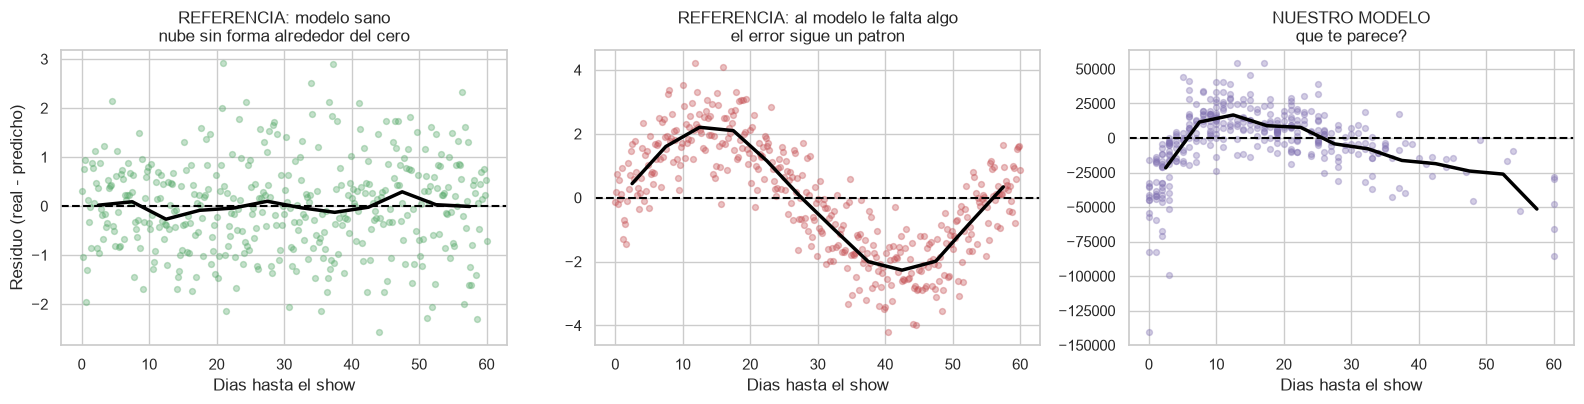

In [23]:
generador = np.random.default_rng(SEMILLA)
eje = np.linspace(0, 60, 400)

sano = generador.normal(0, 1, 400)
con_patron = 2.2 * np.sin(eje / 9) + generador.normal(0, 0.8, 400)
residuos = y_test - lineal.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for ax, (x_dato, y_dato, titulo, color) in zip(axes, [
        (eje, sano, "REFERENCIA: modelo sano\nnube sin forma alrededor del cero", "#55A868"),
        (eje, con_patron, "REFERENCIA: al modelo le falta algo\nel error sigue un patron", "#C44E52"),
        (X_test["dias_hasta_el_show"], residuos, "NUESTRO MODELO\nque te parece?", "#8172B2")]):
    ax.scatter(x_dato, y_dato, alpha=0.35, s=18, color=color)
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
    tramos_res = pd.cut(pd.Series(np.asarray(x_dato)), bins=np.arange(0, 62, 5))
    promedio = pd.Series(np.asarray(y_dato)).groupby(tramos_res, observed=True).mean()
    ax.plot([i.mid for i in promedio.index], promedio.values, color="black", linewidth=2.5)
    ax.set_title(titulo)
    ax.set_xlabel("Dias hasta el show")

axes[0].set_ylabel("Residuo (real - predicho)")
plt.tight_layout()
plt.show()

La línea negra es el **error promedio por tramo**. En un modelo sano va pegada al cero. En el del medio no: se queda corto en unos tramos y se pasa en otros, **siempre en la misma dirección**.

**El nuestro se parece al del medio.** Y fijate la forma que dibuja: **es la joroba de la sección 5.**

No es casualidad. Es la explicación completa de por qué el modelo anda mal:

1. Los días importan muchísimo, pero **en forma de joroba**.
2. Una regresión lineal solo traza **rectas**, y una recta no puede hacer una joroba.
3. Entonces ese efecto **no entra al modelo**, y lo que el modelo no explica queda en el error.
4. Por eso los residuos tienen **la forma de lo que le faltó**.

O sea: los residuos no solo avisan que algo anda mal, te dicen **qué**. Es el diagnóstico; la cura está en la sección 10.

---
## 9. Underfitting y overfitting

Los dos problemas que le pueden pasar a cualquier modelo, y se arreglan con cosas **opuestas**:

- **Underfitting**: demasiado simple para la forma de los datos. Malo con los datos nuevos **y con los que ya vio**.
- **Overfitting**: tan flexible que memorizó el entrenamiento, ruido incluido. Buenísimo con lo que vio, malo con lo nuevo.

Para verlos limpios: **un experimento aparte** con una sola variable (los días) prediciendo el **multiplicador**. La flexibilidad la damos con **polinomios** — grado 1 es una recta, grado 3 una joroba, grado 10 un serrucho. Sigue siendo regresión lineal: solo agregamos columnas con las potencias.

> El RMSE de acá en más está **en unidades de multiplicador**, no en pesos.

In [24]:
x_dias = vendidas[["dias_hasta_el_show"]].values
y_mult = vendidas["multiplicador"].values
xd_train, xd_test, ym_train, ym_test = train_test_split(
    x_dias, y_mult, test_size=0.25, random_state=SEMILLA)


def modelo_polinomico(grado):
    """Regresion lineal sobre las potencias de la variable, hasta el grado pedido."""
    return make_pipeline(PolynomialFeatures(degree=grado), StandardScaler(), LinearRegression())


for grado in [1, 3]:
    modelo = modelo_polinomico(grado).fit(xd_train, ym_train)
    print(f"Grado {grado}:  RMSE train {rmse(ym_train, modelo.predict(xd_train)):.4f}  "
          f"test {rmse(ym_test, modelo.predict(xd_test)):.4f}  "
          f"R2 test {r2_score(ym_test, modelo.predict(xd_test)):>7.4f}")

Grado 1:  RMSE train 0.4923  test 0.4714  R2 test -0.0011
Grado 3:  RMSE train 0.3728  test 0.3572  R2 test  0.4254


**El grado 1 tiene underfitting, y se nota por dos cosas:**

1. **Es igual de malo en train que en test** (0,49 y 0,47): no hay brecha. No memoriza, **no puede** hacerlo mejor.
2. **Un modelo apenas más flexible le pasa por arriba**: el R² salta de **0% a 43%**.

Y no hay dato adicional que lo arregle: la recta va a seguir siendo una recta.

**¿Y si le damos mucha flexibilidad?** Pasamos a una muestra de 50, porque el sobreajuste aparece con mucha flexibilidad y **pocos** datos.

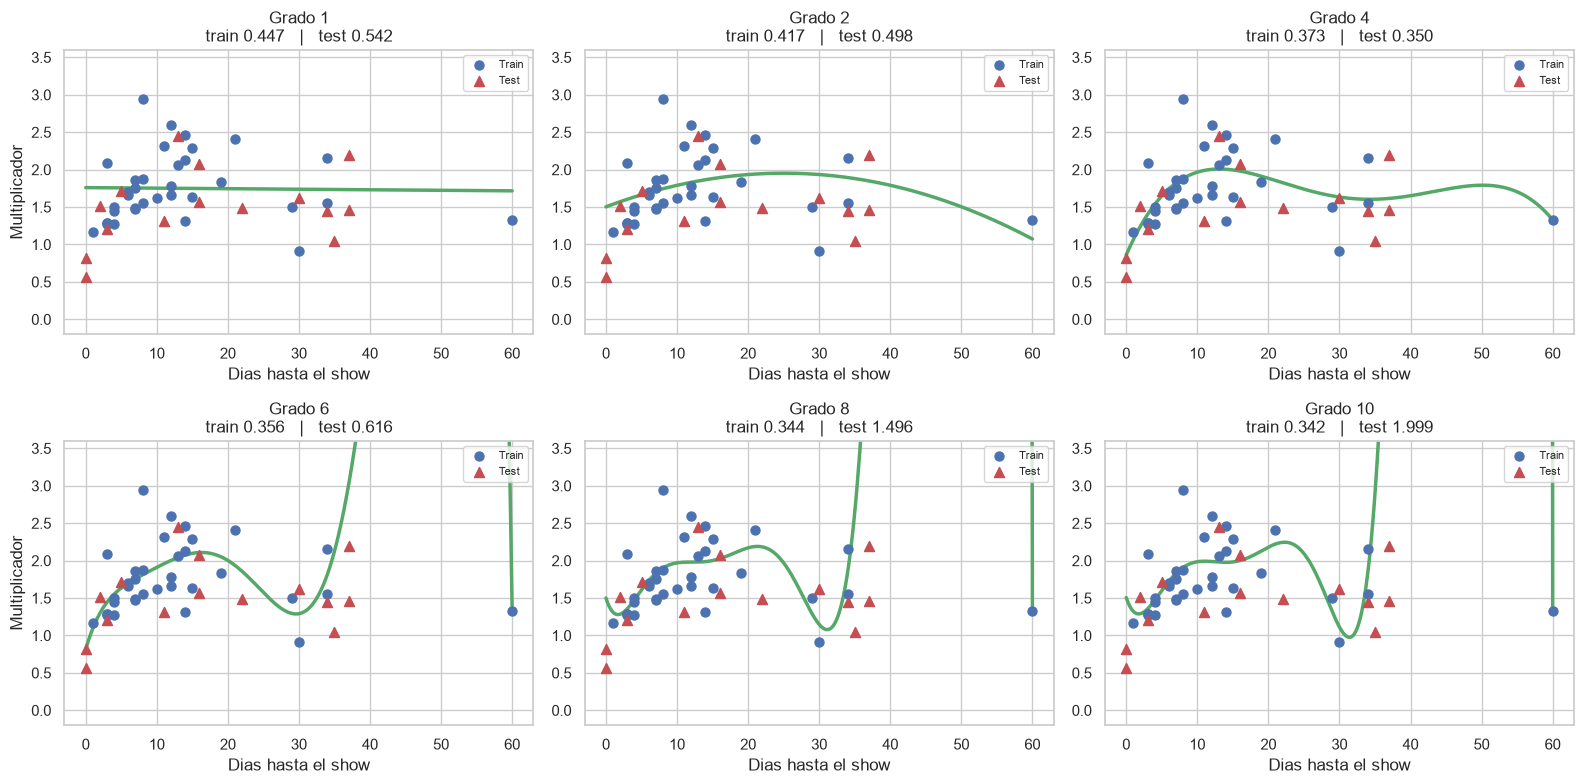

In [25]:
muestra = vendidas.sample(50, random_state=28)
x_m = muestra[["dias_hasta_el_show"]].values
y_m = muestra["multiplicador"].values
x_tr, x_te, y_tr, y_te = train_test_split(x_m, y_m, test_size=0.3, random_state=28)
grilla_x = np.linspace(0, 60, 300).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, grado in zip(axes.flat, [1, 2, 4, 6, 8, 10]):
    modelo = modelo_polinomico(grado).fit(x_tr, y_tr)
    e_tr = rmse(y_tr, modelo.predict(x_tr))
    e_te = rmse(y_te, modelo.predict(x_te))
    ax.scatter(x_tr, y_tr, s=42, color="#4C72B0", label="Train", zorder=3)
    ax.scatter(x_te, y_te, s=52, color="#C44E52", marker="^", label="Test", zorder=3)
    ax.plot(grilla_x, modelo.predict(grilla_x), color="#55A868", linewidth=2.5, zorder=2)
    ax.set_ylim(-0.2, 3.6)
    ax.set_title(f"Grado {grado}\ntrain {e_tr:.3f}   |   test {e_te:.3f}")
    ax.set_xlabel("Dias hasta el show")
    ax.legend(loc="upper right", fontsize=8)
axes[0, 0].set_ylabel("Multiplicador")
axes[1, 0].set_ylabel("Multiplicador")
plt.tight_layout()
plt.show()

**Este es el gráfico de la clase.** Los tres regímenes:

- **Grado 1** — underfitting: la recta no se entera de la joroba.
- **Grados 2 y 4** — el punto justo: sigue la forma real e **ignora los puntos sueltos**.
- **Grados 6, 8 y 10** — overfitting: se retuerce para pasar cerca de **cada punto azul**.

El **train baja siempre** mientras el **test se dispara**: dejó de aprender cómo funciona el mercado para aprender dónde estaba cada uno de estos 35 puntos.

**Pregunta:** en el grado 10, ¿qué le sugiere a alguien que publica **a 55 días**?

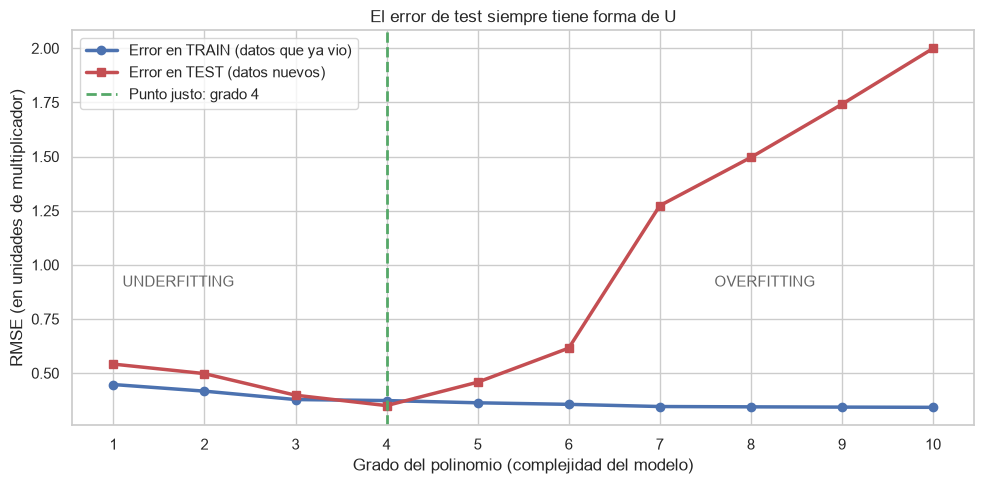

Grado     RMSE train   RMSE test   Brecha (test/train)
------------------------------------------------------
1             0.4474      0.5417                 1.21x
2             0.4169      0.4978                 1.19x
3             0.3781      0.3981                 1.05x
4             0.3734      0.3501                 0.94x
5             0.3631      0.4582                 1.26x  <-- sobreajusta
6             0.3560      0.6156                 1.73x  <-- sobreajusta
7             0.3459      1.2732                 3.68x  <-- sobreajusta
8             0.3444      1.4960                 4.34x  <-- sobreajusta
9             0.3432      1.7415                 5.07x  <-- sobreajusta
10            0.3422      1.9991                 5.84x  <-- sobreajusta


In [26]:
grados_barrido = range(1, 11)
err_train, err_test = [], []
for grado in grados_barrido:
    modelo = modelo_polinomico(grado).fit(x_tr, y_tr)
    err_train.append(rmse(y_tr, modelo.predict(x_tr)))
    err_test.append(rmse(y_te, modelo.predict(x_te)))
grado_optimo = list(grados_barrido)[int(np.argmin(err_test))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grados_barrido, err_train, marker="o", linewidth=2.5, color="#4C72B0",
        label="Error en TRAIN (datos que ya vio)")
ax.plot(grados_barrido, err_test, marker="s", linewidth=2.5, color="#C44E52",
        label="Error en TEST (datos nuevos)")
ax.axvline(grado_optimo, color="#55A868", linestyle="--", linewidth=2,
           label=f"Punto justo: grado {grado_optimo}")
ax.annotate("UNDERFITTING", xy=(1.1, max(err_test) * 0.45), fontsize=11, color="#666666")
ax.annotate("OVERFITTING", xy=(7.6, max(err_test) * 0.45), fontsize=11, color="#666666")
ax.set_xlabel("Grado del polinomio (complejidad del modelo)")
ax.set_ylabel("RMSE (en unidades de multiplicador)")
ax.set_title("El error de test siempre tiene forma de U")
ax.set_xticks(list(grados_barrido))
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Grado':<8}{'RMSE train':>12}{'RMSE test':>12}{'Brecha (test/train)':>22}")
print("-" * 54)
for grado in grados_barrido:
    brecha = err_test[grado - 1] / err_train[grado - 1]
    alarma = "  <-- sobreajusta" if brecha > 1.25 else ""
    print(f"{grado:<8}{err_train[grado - 1]:>12.4f}{err_test[grado - 1]:>12.4f}{brecha:>21.2f}x{alarma}")

**Si te llevás un solo gráfico de esta clase, que sea este.**

- **La azul (train) baja siempre.** Por eso el error de entrenamiento **es inútil como medida de calidad**.
- **La roja (test) tiene forma de U**: baja mientras captura señal, toca fondo, y sube cuando lo único que queda es ruido.
- **La distancia entre las dos es la cantidad de overfitting.**

**¿Y con 40 variables, donde no podés dibujar nada?** Mirás la **brecha** de la tabla (test/train): arranca en 1,2 y termina en casi 6.

**La trampa:** el grado 1 tiene la brecha cerrada —"sano"— y aun así es peor que el grado 4. **Brecha cerrada no quiere decir modelo bueno.** Por eso el diagnóstico necesita **dos** preguntas: *¿la brecha está abierta?* y *¿un modelo más flexible le gana?*

In [27]:
def dibujar_grado(grado):
    modelo = modelo_polinomico(grado).fit(x_tr, y_tr)
    e_tr = rmse(y_tr, modelo.predict(x_tr))
    e_te = rmse(y_te, modelo.predict(x_te))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(x_tr, y_tr, s=48, color="#4C72B0", label="Train", zorder=3)
    ax.scatter(x_te, y_te, s=58, color="#C44E52", marker="^", label="Test", zorder=3)
    ax.plot(grilla_x, modelo.predict(grilla_x), color="#55A868", linewidth=3, zorder=2)
    ax.set_ylim(-0.4, 3.8)
    ax.set_xlabel("Dias hasta el show")
    ax.set_ylabel("Multiplicador")
    ax.set_title(f"Grado {grado}   |   train {e_tr:.3f}   |   test {e_te:.3f}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


if HAY_WIDGETS:
    interact(dibujar_grado, grado=IntSlider(min=1, max=10, step=1, value=4, description="Grado:"))
else:
    dibujar_grado(4)

interactive(children=(IntSlider(value=4, description='Grado:', max=10, min=1), Output()), _dom_classes=('widge…

### Cómo se arregla cada uno

| | Underfitting | Overfitting |
|---|---|---|
| **Más datos** | No sirve de nada | **Lo cura** |
| **Más complejidad** | **Lo cura** | Lo empeora |
| **Menos variables** | Lo empeora | Ayuda |
| **Mejores variables** | **Lo cura** | Ayuda |

Diagnosticar mal cuesta caro: si tenés underfitting y pedís presupuesto para comprar más datos, tirás la plata.

---
## 10. El arreglo: darle al modelo lo que le falta

Ya sabemos qué le falta: los días. Se los damos en dos pasos.

1. **Que pueda curvarse**: le agregamos `dias²` y `dias³`.
2. **Que pueda multiplicar**: el efecto de los días es un **porcentaje del valor de lista**, no una cantidad fija de pesos (sección 5). Un modelo lineal solo **suma**, así que hay que dárselo ya multiplicado: son los **términos de interacción**.

In [28]:
dias_col = X["dias_hasta_el_show"]
forma_dias = np.log(dias_col + 1)

X_curvo = X.copy()
X_curvo["dias_al_cuadrado"] = dias_col ** 2
X_curvo["dias_al_cubo"] = dias_col ** 3

X_final = X_curvo.copy()
X_final["forma_dias"] = forma_dias
X_final["forma_dias_cuad"] = forma_dias ** 2
X_final["lista_por_forma"] = X["precio_original"] * forma_dias
X_final["lista_por_forma_cuad"] = X["precio_original"] * forma_dias ** 2

filas = [tabla_metricas("Lineal original", lineal, X_train, y_train, X_test, y_test)]
for nombre, datos in [("+ dias^2 y dias^3", X_curvo), ("+ interacciones", X_final)]:
    Xa, Xb, ya, yb = train_test_split(datos, y, test_size=0.25, random_state=SEMILLA)
    modelo = make_pipeline(StandardScaler(), LinearRegression()).fit(Xa, ya)
    filas.append(tabla_metricas(nombre, modelo, Xa, ya, Xb, yb))
    if nombre == "+ dias^2 y dias^3":
        curvo, Xcu_train, Xcu_test, ycu_train, ycu_test = modelo, Xa, Xb, ya, yb
    else:
        final, Xf_train, Xf_test, yf_train, yf_test = modelo, Xa, Xb, ya, yb

pd.DataFrame(filas).style.format({"RMSE train": "{:,.0f}", "RMSE test": "{:,.0f}",
                                  "MAE test": "{:,.0f}", "R2 train": "{:.4f}",
                                  "R2 test": "{:.4f}"}).hide(axis="index")

Modelo,RMSE train,RMSE test,MAE test,R2 train,R2 test
Lineal original,"24,280","24,520","17,686",0.8297,0.7734
+ dias^2 y dias^3,"17,977","17,761","12,851",0.9066,0.8811
+ interacciones,"15,532","13,863","10,377",0.9303,0.9276


**De 0,77 a 0,88 a 0,93**, y el error en pesos cae casi a la mitad.

Lo importante es de dónde salió: **no de un algoritmo**. Es el mismo `LinearRegression` de la sección 8. Salió de un gráfico. Eso es **feature engineering**.

¿Y reconstruye la joroba?

In [29]:
pred_final = final.predict(Xf_test)
mae_final = mean_absolute_error(yf_test, pred_final)

reales = vendidas.loc[Xf_test.index].copy()
reales["multiplicador_sugerido"] = pred_final / reales["precio_original"]

momentos = [
    ("Falta mas de un mes", reales["dias_hasta_el_show"] >= 35),
    ("Entre 7 y 20 dias, show agotado",
     reales["dias_hasta_el_show"].between(7, 20) & (reales["show_agotado_en_preventa"] == 1)),
    ("El show es hoy o maniana", reales["dias_hasta_el_show"] <= 1),
]

print(f"R2 {r2_score(yf_test, pred_final):.4f} | MAE {pesos(mae_final)} "
      f"({100 * mae_final / y.median():.1f}% del precio mediano)\n")

pd.DataFrame([{
    "Momento": etiqueta,
    "Publicaciones": int(filtro.sum()),
    "Multiplicador real": f"{reales.loc[filtro, 'multiplicador'].median():.2f}x",
    "Multiplicador sugerido": f"{reales.loc[filtro, 'multiplicador_sugerido'].median():.2f}x",
} for etiqueta, filtro in momentos]).style.hide(axis="index")

R2 0.9276 | MAE $10.377 (14.0% del precio mediano)



Momento,Publicaciones,Multiplicador real,Multiplicador sugerido
Falta mas de un mes,30,1.25x,1.19x
"Entre 7 y 20 dias, show agotado",39,2.32x,2.34x
El show es hoy o maniana,25,0.87x,0.88x


**Reconstruyó la joroba casi exacta, y nadie se la enseñó:** 1,2x a más de un mes, 2,3x en la ventana caliente, y el día del show **por debajo del valor de lista**.

Le erramos **$10.400** sobre un precio mediano de $74.000: un 14%. Para un número exacto no alcanza; para una **banda** sirve, que es lo que pidió tu jefa.

---
## 11. Segunda pregunta: ¿se va a vender?

El vendedor puede ignorar nuestra sugerencia y pedir lo que quiera. Ahí aparece la pregunta que de verdad le importa al negocio: **si publico a este precio, ¿se vende?**

Antes predecíamos un número (regresión); ahora **sí o no**: es **clasificación**, como en la Clase 05. Y volvemos a usar **todas** las publicaciones, porque las no vendidas son la mitad interesante.

In [30]:
df["multiplicador_pedido"] = df["precio_publicado"] / df["precio_original"]

# OJO: precio_reventa y comision_plataforma estan vacias justo en las que no se vendieron.
# Dejarlas seria regalarle la respuesta al modelo: es el mismo leakage de la seccion 6.3.
fuera_clasificacion = ["id_publicacion", "precio_original_con_cargos", "cantidad_fotos_publicacion",
                       "comision_plataforma", "tipo_venue", "precio_reventa", "se_vendio"]

X_clas = pd.get_dummies(df.drop(columns=fuera_clasificacion), drop_first=True, dtype=int)
y_clas = df["se_vendio"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clas, y_clas, test_size=0.25, random_state=SEMILLA, stratify=y_clas)

print(f"{len(X_clas)} publicaciones | se vendio el {100 * y_clas.mean():.1f}%")
print(f"Entrenamiento: {len(Xc_train)} | Test: {len(Xc_test)}")

2163 publicaciones | se vendio el 64.4%
Entrenamiento: 1622 | Test: 541


**Antes de entrenar nada, el baseline.** Si predecimos "se vende" para todo el mundo, acertamos el 64% de las veces, porque ese es el porcentaje que se vende. **Cualquier modelo tiene que superar ese 64% para valer algo.** Es el primer número que hay que calcular en toda clasificación, y el que más se olvida.

In [31]:
logistica = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=2000)).fit(Xc_train, yc_train)
pred_clas = logistica.predict(Xc_test)

print(f"Baseline (predecir siempre 'se vende'): {yc_test.mean():.4f}")
print(f"Accuracy de la regresion logistica:     {accuracy_score(yc_test, pred_clas):.4f}\n")
print(pd.DataFrame(confusion_matrix(yc_test, pred_clas),
                   index=["Real: NO se vendio", "Real: se vendio"],
                   columns=["Predijo NO", "Predijo SI"]).to_string())

Baseline (predecir siempre 'se vende'): 0.6433
Accuracy de la regresion logistica:     0.8170

                    Predijo NO  Predijo SI
Real: NO se vendio         128          65
Real: se vendio             34         314


**82% contra un baseline de 64%.** El modelo aprendió algo real.

La **matriz de confusión** es lo que hay que mirar, no la accuracy sola. Lo que más importa es la fila de arriba: las que **no se vendieron**. Si el modelo le dice "se vende" a alguien que va a pedir demasiado, lo dejamos publicar un precio que no va a funcionar — justo el problema que nos pidieron resolver.

### 11.1 Qué pasa si no estandarizás

Lo mostramos con **KNN**, que para clasificar busca las **k publicaciones más parecidas** y vota entre ellas. Lo que define "parecida" es la **distancia**: resta cada variable, la eleva al cuadrado y suma.

In [32]:
knn_crudo = KNeighborsClassifier(n_neighbors=40).fit(Xc_train, yc_train)
knn_escalado = make_pipeline(StandardScaler(),
                             KNeighborsClassifier(n_neighbors=40)).fit(Xc_train, yc_train)

for nombre, modelo in [("KNN k=40 SIN escalar", knn_crudo), ("KNN k=40 escalado", knn_escalado)]:
    print(f"{nombre:24s} accuracy {accuracy_score(yc_test, modelo.predict(Xc_test)):.4f}")
print(f"{'(baseline)':24s} accuracy {yc_test.mean():.4f}")

KNN k=40 SIN escalar     accuracy 0.6784
KNN k=40 escalado        accuracy 0.7357
(baseline)               accuracy 0.6433


**Sin escalar, KNN apenas le gana a no hacer nada** (0,68 contra un baseline de 0,64). Con el mismo algoritmo, la misma `k` y los mismos datos, escalado sube a 0,74.

¿Por qué? Descompongamos la distancia entre dos publicaciones.

In [33]:
aporte = (Xc_train.iloc[0] - Xc_train.iloc[1]) ** 2
pd.DataFrame({
    "Publicacion A": Xc_train.iloc[0],
    "Publicacion B": Xc_train.iloc[1],
    "Aporte a la distancia": aporte,
    "% del total": 100 * aporte / aporte.sum(),
}).sort_values("% del total", ascending=False).head(4).style.format({
    "Publicacion A": "{:,.1f}", "Publicacion B": "{:,.1f}",
    "Aporte a la distancia": "{:,.1f}", "% del total": "{:.4f}%"})

,Publicacion A,Publicacion B,Aporte a la distancia,% del total
oyentes_mensuales_spotify,"39,603,335.0","29,972,921.0","92,744,873,811,396.0",99.9930%
precio_publicado,"92,000.0","165,000.0","5,329,000,000.0",0.0057%
precio_original,"41,000.0","75,000.0","1,156,000,000.0",0.0012%
dias_hasta_el_show,7.0,1.0,36.0,0.0000%


**`oyentes_mensuales_spotify` explica el 99,99% de la distancia.**

Para el modelo sin escalar, dos publicaciones son "parecidas" si el artista tiene oyentes parecidos, **y nada más**. **Una general de Niceto y un palco de River son la misma publicación.**

La causa es aritmética: los oyentes llegan a 60 millones y las dummies valen 0 o 1, así que al elevar al cuadrado una diferencia de un millón aplasta todo lo demás.

Y el detalle que lo hace peligroso: **no está roto del todo**, le gana al baseline por poco. **Está mirando por el ojo de una cerradura**, y eso es peor que estar roto: un modelo a medias pasa a producción sin que nadie lo note.

| Modelo | ¿Necesita escalado? | Por qué |
|---|---|---|
| **KNN** y **clustering** | **Sí, siempre** | Todo se juega en una distancia compartida |
| Con regularización | Sí | El peaje se le cobra a los coeficientes |
| Lineal / logística simple | En teoría no, en la práctica sí | Con rangos extremos la cuenta se vuelve inestable |
| Árboles y Random Forest | No | Cortan variable por variable |

### 11.2 El último número

KNN también tiene su perilla de complejidad: **k**, la cantidad de vecinos que votan. El extremo `k = 1` deja el mejor ejemplo de toda la clase.

In [34]:
knn_1 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)).fit(Xc_train, yc_train)
print(f"Accuracy en TRAIN: {accuracy_score(yc_train, knn_1.predict(Xc_train)):.4f}")
print(f"Accuracy en TEST:  {accuracy_score(yc_test, knn_1.predict(Xc_test)):.4f}")

Accuracy en TRAIN: 1.0000
Accuracy en TEST:  0.6414


**100% de accuracy en entrenamiento**, y en test peor que el modelo de k=40.

No hay misterio: la vecina más cercana de una publicación del training set **es ella misma**.

> **Un modelo con accuracy perfecta en train no es perfecto. Es un modelo que memorizó.**

Es el overfitting de la sección 9 con otro algoritmo y la perilla al revés: en KNN, **menos k es más complejo**.

---
## 12. El dashboard: lo que se lleva a la reunión

Todo lo anterior no le sirve a nadie en la empresa. Nadie va a abrir tu notebook. Lo que se lleva a la reunión del lunes es **esto**: tres gráficos y cuatro números que contestan las preguntas del negocio.

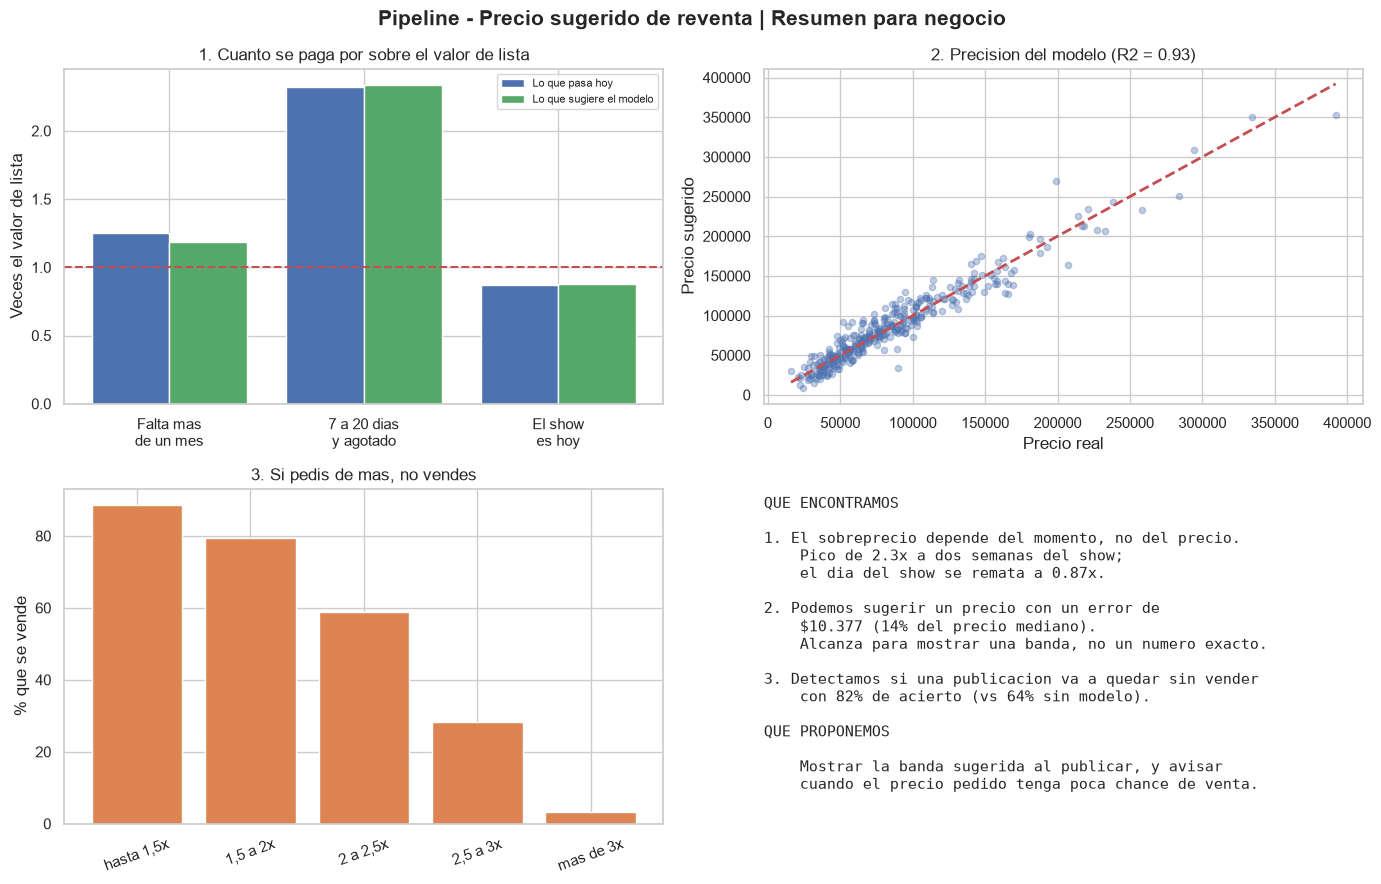

In [35]:
tramos_pedido = pd.cut(df["multiplicador_pedido"], bins=[0, 1.5, 2, 2.5, 3, 10],
                       labels=["hasta 1,5x", "1,5 a 2x", "2 a 2,5x", "2,5 a 3x", "mas de 3x"])
tasa_venta = df.groupby(tramos_pedido, observed=True)["se_vendio"].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Pipeline - Precio sugerido de reventa | Resumen para negocio",
             fontsize=15, fontweight="bold")

# A: la joroba, real vs sugerido
etiquetas = ["Falta mas\nde un mes", "7 a 20 dias\ny agotado", "El show\nes hoy"]
reales_med = [reales.loc[f, "multiplicador"].median() for _, f in momentos]
sugerido_med = [reales.loc[f, "multiplicador_sugerido"].median() for _, f in momentos]
posicion = np.arange(3)
axes[0, 0].bar(posicion - 0.2, reales_med, 0.4, label="Lo que pasa hoy", color="#4C72B0")
axes[0, 0].bar(posicion + 0.2, sugerido_med, 0.4, label="Lo que sugiere el modelo", color="#55A868")
axes[0, 0].axhline(1, color="#C44E52", linestyle="--", linewidth=1.5)
axes[0, 0].set_xticks(posicion)
axes[0, 0].set_xticklabels(etiquetas)
axes[0, 0].set_ylabel("Veces el valor de lista")
axes[0, 0].set_title("1. Cuanto se paga por sobre el valor de lista")
axes[0, 0].legend(fontsize=8)

# B: que tan bien predice
axes[0, 1].scatter(yf_test, pred_final, alpha=0.35, s=20, color="#4C72B0")
limites = [yf_test.min(), yf_test.max()]
axes[0, 1].plot(limites, limites, color="#C44E52", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Precio real")
axes[0, 1].set_ylabel("Precio sugerido")
axes[0, 1].set_title(f"2. Precision del modelo (R2 = {r2_score(yf_test, pred_final):.2f})")

# C: probabilidad de vender segun cuanto pedis
axes[1, 0].bar(range(len(tasa_venta)), tasa_venta.values * 100, color="#DD8452")
axes[1, 0].set_xticks(range(len(tasa_venta)))
axes[1, 0].set_xticklabels(tasa_venta.index, rotation=20)
axes[1, 0].set_ylabel("% que se vende")
axes[1, 0].set_title("3. Si pedis de mas, no vendes")

# D: los numeros
axes[1, 1].axis("off")
resumen = (
    "QUE ENCONTRAMOS\n\n"
    f"1. El sobreprecio depende del momento, no del precio.\n"
    f"    Pico de {max(reales_med):.1f}x a dos semanas del show;\n"
    f"    el dia del show se remata a {min(reales_med):.2f}x.\n\n"
    f"2. Podemos sugerir un precio con un error de\n"
    f"    {pesos(mae_final)} ({100 * mae_final / y.median():.0f}% del precio mediano).\n"
    f"    Alcanza para mostrar una banda, no un numero exacto.\n\n"
    f"3. Detectamos si una publicacion va a quedar sin vender\n"
    f"    con {100 * accuracy_score(yc_test, pred_clas):.0f}% de acierto (vs {100 * yc_test.mean():.0f}% sin modelo).\n\n"
    "QUE PROPONEMOS\n\n"
    "    Mostrar la banda sugerida al publicar, y avisar\n"
    "    cuando el precio pedido tenga poca chance de venta."
)
axes[1, 1].text(0, 0.98, resumen, va="top", ha="left", fontsize=10.5, family="monospace")

plt.tight_layout()
plt.show()

**Eso es el entregable.** Fijate lo que no tiene: ni un nombre de algoritmo, ni una matriz de correlación, ni la palabra "overfitting". Todo eso fue el trabajo, no el resultado.

Y fijate lo que sí tiene: **tres hallazgos y una propuesta concreta**. Si tu jefa solo mira esta imagen, entiende qué encontraste y qué querés hacer.

---
## 13. Comparación de modelos

Todo proyecto termina acá: la tabla de **todo lo que probaste**, con la métrica que corresponde y por qué elegiste el que elegiste. Es lo primero que te va a pedir cualquiera que revise tu trabajo.

In [36]:
from IPython.display import display

# El modelo tramposo de la seccion 6.3, para que quede en la comparacion
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_con_comision, y, test_size=0.25, random_state=SEMILLA)
tramposo = LinearRegression().fit(Xl_train, yl_train)

regresion = pd.DataFrame([
    tabla_metricas("Lineal simple", lineal, X_train, y_train, X_test, y_test),
    tabla_metricas("+ dias^2 y dias^3", curvo, Xcu_train, ycu_train, Xcu_test, ycu_test),
    tabla_metricas("+ interacciones  (ELEGIDO)", final, Xf_train, yf_train, Xf_test, yf_test),
    tabla_metricas("Con comision  (DESCARTADO: leakage)", tramposo,
                   Xl_train, yl_train, Xl_test, yl_test),
])

print("PREGUNTA 1 - a que precio se vende  (regresion, el error esta en pesos)")
display(regresion.style.format({
    "RMSE train": "{:,.0f}", "RMSE test": "{:,.0f}", "MAE test": "{:,.0f}",
    "R2 train": "{:.4f}", "R2 test": "{:.4f}"}).hide(axis="index"))

PREGUNTA 1 - a que precio se vende  (regresion, el error esta en pesos)


Modelo,RMSE train,RMSE test,MAE test,R2 train,R2 test
Lineal simple,"24,280","24,520","17,686",0.8297,0.7734
+ dias^2 y dias^3,"17,977","17,761","12,851",0.9066,0.8811
+ interacciones (ELEGIDO),"15,532","13,863","10,377",0.9303,0.9276
Con comision (DESCARTADO: leakage),"1,891","1,901","1,624",0.9990,0.9986


In [37]:
def fila_clasificacion(nombre, modelo, comentario):
    return {"Modelo": nombre,
            "Accuracy train": accuracy_score(yc_train, modelo.predict(Xc_train)),
            "Accuracy test": accuracy_score(yc_test, modelo.predict(Xc_test)),
            "Comentario": comentario}


clasificacion = pd.DataFrame([
    {"Modelo": "Baseline (siempre 'se vende')", "Accuracy train": yc_train.mean(),
     "Accuracy test": yc_test.mean(), "Comentario": "El piso que hay que superar"},
    fila_clasificacion("KNN k=40 SIN escalar", knn_crudo, "Apenas le gana al baseline"),
    fila_clasificacion("KNN k=40 escalado", knn_escalado, "El mismo, con StandardScaler"),
    fila_clasificacion("KNN k=1 escalado", knn_1, "Perfecto en train: memorizo"),
    fila_clasificacion("Regresion logistica  (ELEGIDO)", logistica, "El unico que despega"),
])

print("PREGUNTA 2 - si se vende o no  (clasificacion)")
display(clasificacion.style.format({
    "Accuracy train": "{:.4f}", "Accuracy test": "{:.4f}"}).hide(axis="index"))

PREGUNTA 2 - si se vende o no  (clasificacion)


Modelo,Accuracy train,Accuracy test,Comentario
Baseline (siempre 'se vende'),0.6443,0.6433,El piso que hay que superar
KNN k=40 SIN escalar,0.6991,0.6784,Apenas le gana al baseline
KNN k=40 escalado,0.7343,0.7357,"El mismo, con StandardScaler"
KNN k=1 escalado,1.0000,0.6414,Perfecto en train: memorizo
Regresion logistica (ELEGIDO),0.8440,0.8170,El unico que despega


**Cómo se lee esta tabla, que es lo que se aprende de ella:**

- **Las métricas no se mezclan entre problemas.** La de arriba está en pesos y R²; la de abajo en accuracy. Comparar un 0,93 de R² con un 0,82 de accuracy no significa nada.
- **El mejor número de todo el notebook es el tramposo.** El modelo con la comisión tiene el RMSE más bajo por lejos y **vale cero**, porque esa columna no existe cuando hay que predecir. Por eso la comparación lleva la columna de comentario: el número solo no alcanza para decidir.
- **En clasificación, la fila del baseline es obligatoria.** Sin ella, el 0,68 del KNN sin escalar parecería un resultado; al lado del 0,64 de adivinar, se ve que no lo es.
- **Mirá siempre train contra test.** KNN con k=1 tiene el mejor train de la tabla y el peor test: es la firma del overfitting, y en una tabla de comparación salta a la vista sin necesidad de ningún gráfico.

---
## 14. Qué llevarse

| # | El problema | Cómo lo detectamos | Qué hicimos |
|---|---|---|---|
| 1 | Datos sucios y valores imposibles | `describe()` y `value_counts()` a **todas** las categóricas | Limpieza mirando dónde cortar |
| 2 | Dos poblaciones mezcladas | Columnas con menos filas | Separamos vendidas de no vendidas |
| 3 | **Correlación cero que engaña** | Dibujar, no mirar el número | El multiplicador → la joroba |
| 4 | **Multicolinealidad** | Un coeficiente negativo absurdo | Sacamos el precio con cargos |
| 5 | **Variable ruido** | R² sin cambios al agregarla | Sacamos la cantidad de fotos |
| 6 | **Data leakage** | R² sospechoso: ¿de dónde sale esta columna? | Sacamos la comisión |
| 7 | Error sistemático | Residuos contra la referencia | Feature engineering |
| 8 | **Underfitting** | Malo en train Y en test | Curvas e interacciones |
| 9 | **Overfitting** | Brecha test/train grande | Menos complejidad |
| 10 | **Falta de escalado** | Descomponer la distancia | `StandardScaler()` |

### Las cinco frases

1. **El error de entrenamiento no sirve por sí solo.** KNN con k=1 tiene 100% en train y es un desastre.
2. **La brecha train/test es tu alarma de sobreajuste**, con 1 variable o con 400.
3. **Overfitting y underfitting se arreglan con cosas opuestas.**
4. **En clasificación, calculá el baseline primero.** 82% suena bien hasta que ves que adivinando sacás 64%.
5. **Lo que más movió la aguja no fue ningún algoritmo.** El modelo final es el mismo `LinearRegression` del principio: pasó de 0,77 a 0,93 porque entendimos el negocio. **El oficio está antes del `.fit()`.**

### Lo que viene

Cross-validation y `GridSearchCV` (elegir el grado sin espiar el test), los **árboles**, que encuentran las interacciones solos, y precision/recall/umbral para la parte de clasificación.

---
## Para ver en casa

1. **El umbral.** La logística devuelve una probabilidad: `predict_proba()`. Probá cortar en 0,3 y en 0,7 en vez de 0,5. ¿Qué le pasa a la matriz de confusión? ¿Cuál convendría para avisarle al vendedor que su precio es muy alto?

2. **La escala.** Reemplazá `oyentes_mensuales_spotify` por `np.log10(oyentes)` y reentrená. ¿Cambia el R²? ¿Y qué le pasa al KNN sin escalar de la sección 11.1?

3. **Traer datos de afuera.** ¿Qué otra variable podría mover el precio de reventa y no está en el dataset? Elegí una, explicá de dónde la sacarías y por qué debería servir.

4. **El leakage.** Volvé a meter `comision_plataforma` y entrená. Ahora simulá producción: pasale tres publicaciones nuevas sin esa columna. ¿Qué pasa?